In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

df = pd.read_csv('https://github.com/Explore-AI/Public-Data/blob/master/exports%20ZAR-USD-data.csv?raw=true', index_col=0)
df.columns = ['Y', 'X']

In [2]:
X = df.X.values
Y = df.Y.values
x_bar = np.mean(X)
y_bar = np.mean(Y)

m = sum((X - x_bar) * (Y - y_bar)) / sum((X - x_bar) ** 2)

c = y_bar - m * x_bar

print("Slope = ", m)
print("Intercept= ", c)

Slope =  0.000113507257658843
Intercept=  1.8448114670426463


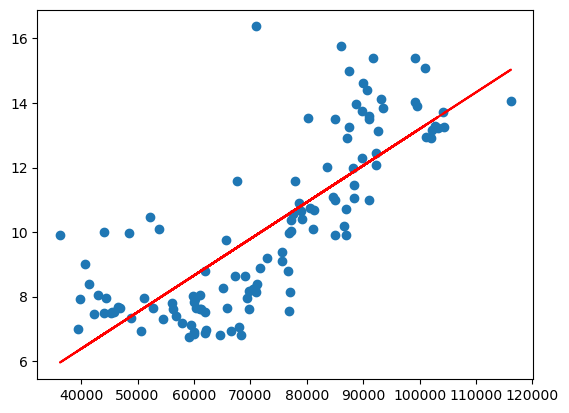

In [3]:
def gen_y(x_list, m, c):
    y_gen = []
    for x_i in x_list:
        y_i = m*x_i + c
        y_gen.append(y_i)

    return(y_gen)
y_gen = m * df.X + c
plt.scatter(df.X, df.Y)
plt.plot(df.X, y_gen, color='red')
plt.show()

In [4]:
errors2 = np.array(y_gen - df.Y)
print(np.round(errors2, ))

[-1. -0. -0.  0.  1.  1.  1.  1.  1. -0. -2. -3. -4. -3. -3. -3. -2. -1.
 -1. -2. -1. -1. -0. -0. -1. -1.  1.  0.  0.  1.  1.  1.  1.  2.  2.  2.
  1.  1.  2.  2.  2.  3.  2.  2.  3.  2.  2.  2.  1.  2.  2.  1.  2.  2.
  2.  2.  1.  1.  2.  1.  0.  1.  1.  1.  1.  1.  2.  1.  1.  2.  1.  0.
 -0.  1.  0.  0.  0.  0.  1.  0.  1.  1.  0.  0. -2. -1.  0. -1. -0. -0.
 -0. -1. -1. -2. -2. -3. -6. -4. -3. -3. -2. -2. -2. -2. -1. -2. -1. -1.
 -3. -1.  0. -1.  0.  1. -1.  0.  0. -0.  1.  0.]


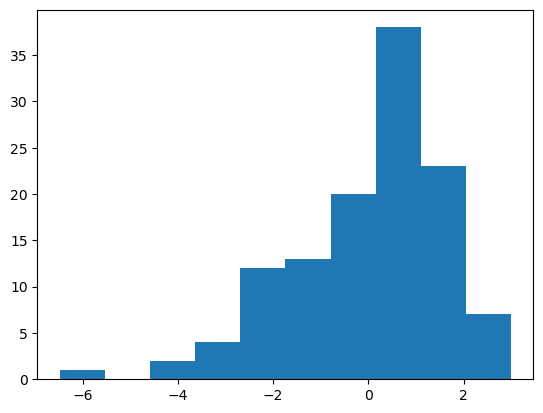

In [5]:
plt.hist(errors2)
plt.show()

In [6]:
print("Residal sum of squares:", (errors2 ** 2).sum())

Residal sum of squares: 321.45716655257655


In [7]:
np.round(errors2.sum(), 11)

-0.0

## Linear Regression in sci-kit learn

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lm = LinearRegression()

In [10]:
X = df.X.values[:, np.newaxis]

In [11]:
lm.fit(X, df.Y)

LinearRegression()

In [12]:
m = lm.coef_[0]
c = lm.intercept_

In [13]:
print("slope:\t\t", m)
print("Intercept:\t", c)

slope:		 0.00011350725765884303
Intercept:	 1.8448114670426445


In [14]:
gen_y = lm.predict(X)

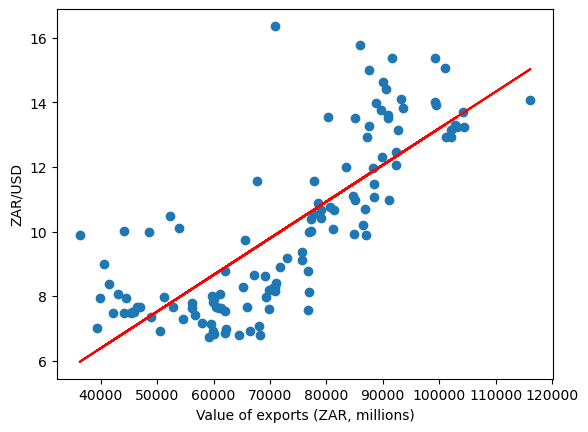

In [16]:
plt.scatter(X, df.Y)
plt.plot(X, gen_y, color='red')

plt.ylabel("ZAR/USD")
plt.xlabel("Value of exports (ZAR, millions)")
plt.show()

In [17]:
print("Residual sum of squares:", ((gen_y - df.Y) ** 2).sum())

Residual sum of squares: 321.45716655257655


## Sci-kit learn error metrics

In [20]:
from sklearn import metrics

In [22]:
print('MSE:', metrics.mean_squared_error(df.Y, gen_y))

MSE: 2.678809721271471


In [23]:
print('Residual sum of squares:', metrics.mean_squared_error(df.Y, gen_y) * len(X))

Residual sum of squares: 321.45716655257655


In [24]:
print('R_squared:', metrics.r2_score(df.Y, gen_y))

R_squared: 0.6158417476896207
